## Improts

In [1]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import re
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Display settings for readable outputs
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


##  Load the Dataset

In [2]:
# Cell 2: Load Symptom2Disease CSV
# The dataset has two useful columns: 'label' (disease) and 'text' (symptom description)

df = pd.read_csv('../datasets/pky.csv')

# Drop index column if it exists (Kaggle CSV often has 'Unnamed: 0')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Number of unique diseases: {df['label'].nunique()}")
df.head()


Dataset shape: (1375, 2)
Columns: ['label', 'text']
Number of unique diseases: 27


,label,text
0,Psoriasis,"I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is r..."
1,Psoriasis,"My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accom..."
2,Psoriasis,"I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and..."
3,Psoriasis,"There is a silver like dusting on my skin, especially on my lower back and scalp. This dusting i..."
4,Psoriasis,"My nails have small dents or pits in them, and they often feel inflammatory and tender to the to..."


## Explore Class Distribution

label
Dengue                             75
Hypertension                       75
Migraine                           75
peptic ulcer disease               75
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                               50
Bronchial Asthma                   50
Cervical spondylosis               50
Jaundice                           50
Malaria                            50
urinary tract infection            50
allergy                            50
gastroesophageal reflux disease    50
drug reaction                      50
diabetes                           50
Drug Reaction                      25
Allergy                            25
Diabet

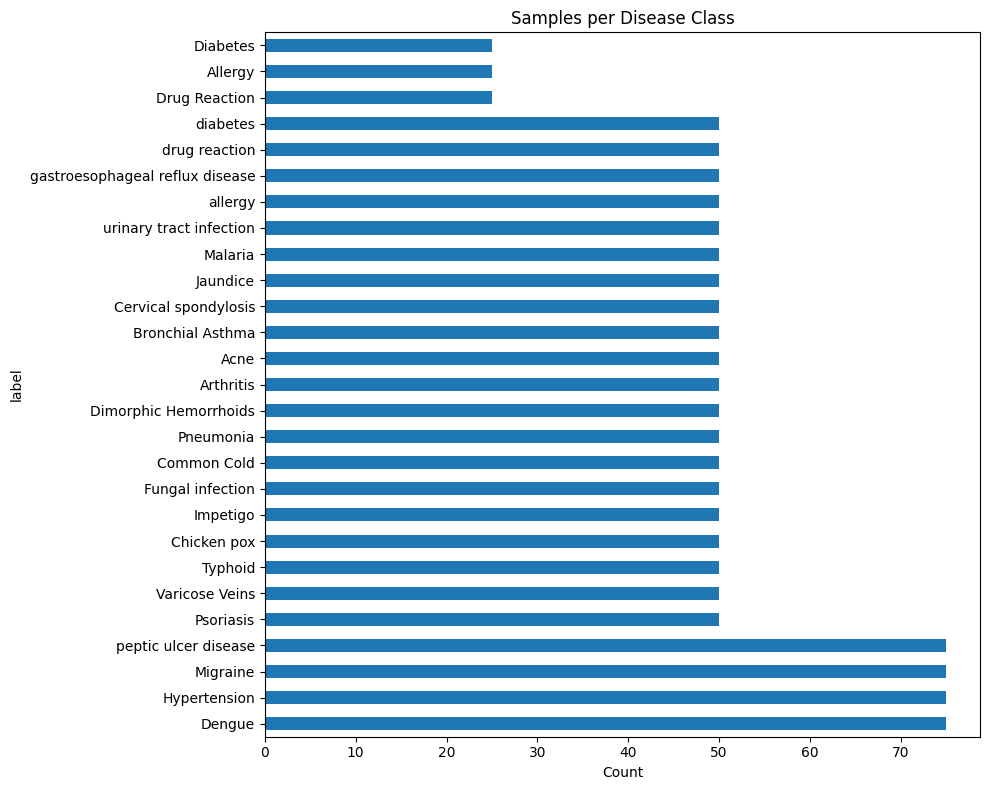

In [3]:
# Cell 3: Check class balance
class_counts = df['label'].value_counts()
print(class_counts)

plt.figure(figsize=(10, 8))
class_counts.plot(kind='barh')
plt.title('Samples per Disease Class')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../models/nlp_class_distribution.png', dpi=100)
plt.show()

## Text Cleaning

In [4]:
# Cell 4: Clean labels and apply text cleaning
# IMPORTANT: the clean_text function must be used identically inside FastAPI at inference time

# -----------------------------
# Label cleaning — case normalization only
# -----------------------------

# Fix: Normalize label case — merge capitalized augmented labels with the 
# original lowercase dataset labels
df['label'] = df['label'].replace({
    'Diabetes': 'diabetes',
    'Allergy': 'allergy',
    'Drug Reaction': 'drug reaction'
})

# Safety: strip whitespace from labels (no data loss, purely cosmetic)
df['label'] = df['label'].str.strip()

print(f"Dataset size: {len(df)} rows")
print(f"Number of unique classes: {df['label'].nunique()}")
print("\nClass distribution:")
print(df['label'].value_counts().sort_values())

# -----------------------------
# Text cleaning
# -----------------------------

def clean_text(text):
    """Lowercase, remove special characters, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # keep letters, digits, spaces
    text = re.sub(r'\s+', ' ', text).strip()   # collapse multiple spaces
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# Quick before/after check
print("\n--- Text cleaning verification ---")
print("Before:", df['text'].iloc[0])
print("After :", df['cleaned_text'].iloc[0])

# Cell 4b: Shuffle the dataset
# Critical step — augmented rows were appended at the bottom,
# and unshuffled data weakens stratified splitting

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shuffled. Size: {len(df)} rows")
print("\nFirst 10 rows after shuffle (should show mixed classes):")
print(df[['label', 'text']].head(10))

Dataset size: 1375 rows
Number of unique classes: 24

Class distribution:
label
Psoriasis                          50
Pneumonia                          50
Common Cold                        50
Fungal infection                   50
Impetigo                           50
Chicken pox                        50
Typhoid                            50
Varicose Veins                     50
Dimorphic Hemorrhoids              50
urinary tract infection            50
Malaria                            50
Jaundice                           50
Cervical spondylosis               50
Bronchial Asthma                   50
Acne                               50
Arthritis                          50
gastroesophageal reflux disease    50
allergy                            75
Migraine                           75
Dengue                             75
peptic ulcer disease               75
drug reaction                      75
diabetes                           75
Hypertension                       75
Name: co

##  Stratified Train-Test Split

In [5]:
# Cell 5: 80/20 stratified split
# Stratify ensures all 24 classes appear in both train and test proportionally

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Train class count: {y_train.nunique()}")
print(f"Test class count:  {y_test.nunique()}")

Training samples: 1100
Testing samples: 275
Train class count: 24
Test class count:  24


## TF-IDF Vectorization

In [6]:
# Cell 6: Convert text to TF-IDF vectors
# max_features caps vocabulary size; ngram_range=(1,2) captures single words AND 2-word phrases
# (e.g., "chest pain" as one feature, not just "chest" + "pain" separately)

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF matrix shape (train): (1100, 3000)
Vocabulary size: 3000


##  Train Multinomial Naive Bayes 

In [7]:
# Cell 7: Train the classifier
# fit_prior=False uses uniform class priors — helps when classes are slightly imbalanced

model = MultinomialNB(fit_prior=False)
model.fit(X_train_tfidf, y_train)

print("Model trained successfully.")
print(f"Number of classes learned: {len(model.classes_)}")

Model trained successfully.
Number of classes learned: 24


## Evaluate on Test Set

In [8]:
# Cell 8: Evaluate accuracy + classification report
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9200

Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.73      0.80      0.76        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.80      0.80      0.80        15
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.91      1.00      0.95        10
                   Hypertension       0.93      0.87      0.90        15
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
    

## 5-Fold Cross-Validation

In [9]:
# Cell 9: Cross-validation for a more honest accuracy estimate
# Fits and evaluates on 5 different splits of the full dataset

X_full_tfidf = vectorizer.transform(df['cleaned_text'])
cv_scores = cross_val_score(model, X_full_tfidf, df['label'], cv=5, scoring='accuracy')

print(f"5-Fold CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV Scores: [0.92       0.91636364 0.94181818 0.95272727 0.94909091]
Mean CV Accuracy: 0.9360 (+/- 0.0150)


 ## Confusion Matrix

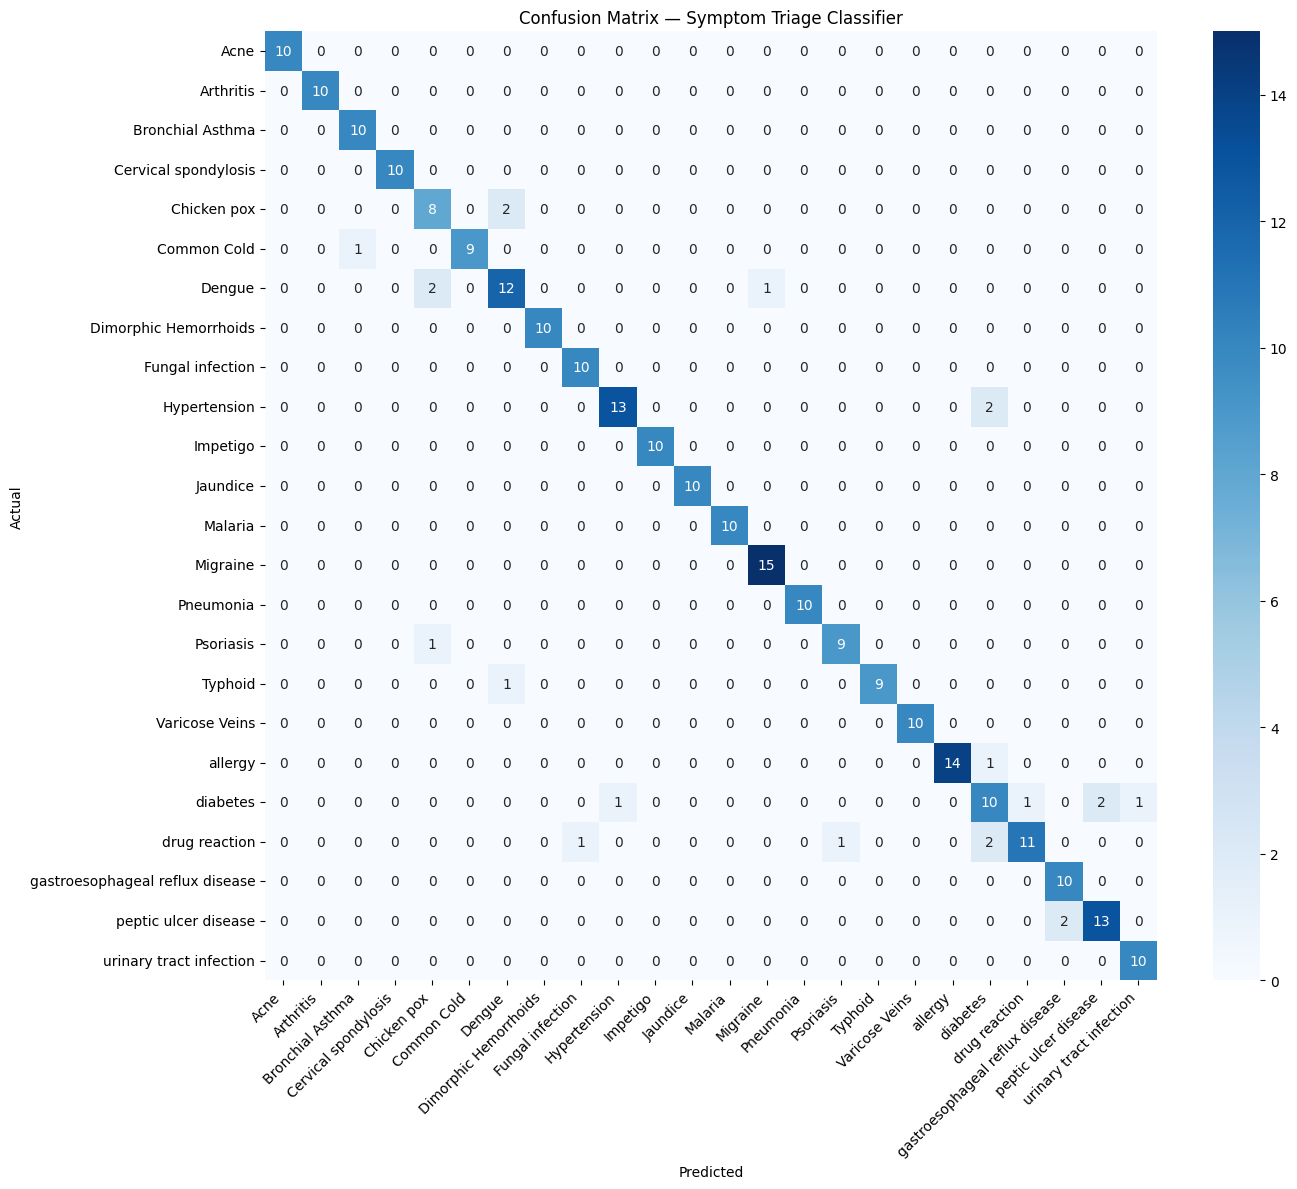

In [10]:
# Cell 10: Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Confusion Matrix — Symptom Triage Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../models/nlp_confusion_matrix.png', dpi=100)
plt.show()

## drug reaction

In [11]:
# Cell 11: Test the model on realistic patient-style inputs
# This is a smoke test before we save the artifacts

test_samples = [
    "I have severe chest pain and shortness of breath",
    "My skin is itchy and has a red rash all over",
    "I have a terrible headache and sensitivity to light",
    "I feel constant thirst and I'm urinating very frequently",
    "I have stomach pain and diarrhea"
]

for sample in test_samples:
    cleaned = clean_text(sample)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    confidence = model.predict_proba(vec).max()
    print(f"Input:      {sample}")
    print(f"Predicted:  {prediction}  (confidence: {confidence:.2%})")
    print("-" * 70)

Input:      I have severe chest pain and shortness of breath
Predicted:  Hypertension  (confidence: 26.57%)
----------------------------------------------------------------------
Input:      My skin is itchy and has a red rash all over
Predicted:  Fungal infection  (confidence: 11.71%)
----------------------------------------------------------------------
Input:      I have a terrible headache and sensitivity to light
Predicted:  Malaria  (confidence: 7.00%)
----------------------------------------------------------------------
Input:      I feel constant thirst and I'm urinating very frequently
Predicted:  diabetes  (confidence: 16.70%)
----------------------------------------------------------------------
Input:      I have stomach pain and diarrhea
Predicted:  Typhoid  (confidence: 19.08%)
----------------------------------------------------------------------


## Save Model Artifacts

In [12]:
# Cell 12: Save model, vectorizer, and label classes
# FastAPI will load these three files at startup

joblib.dump(model, '../models/nlp_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(list(model.classes_), '../models/nlp_label_classes.pkl')

print("Saved:")
print("  ../models/nlp_model.pkl")
print("  ../models/tfidf_vectorizer.pkl")
print("  ../models/nlp_label_classes.pkl")

Saved:
  ../models/nlp_model.pkl
  ../models/tfidf_vectorizer.pkl
  ../models/nlp_label_classes.pkl


##  Create Disease → Specialty Map

In [13]:
# Cell 13: Map every predicted disease to a medical specialty
# CRITICAL: specialty strings must EXACTLY match what Madusanka stores
# in DoctorProfile.specialization — otherwise the MongoDB filter returns nothing

specialty_map = {
    "Psoriasis": "Dermatologist",
    "Varicose Veins": "Vascular Surgeon",
    "Typhoid": "General Physician",
    "Chicken pox": "General Physician",
    "Impetigo": "Dermatologist",
    "Dengue": "General Physician",
    "Fungal infection": "Dermatologist",
    "Common Cold": "General Physician",
    "Pneumonia": "Pulmonologist",
    "Dimorphic Hemorrhoids": "Gastroenterologist",
    "Arthritis": "Orthopedic",
    "Acne": "Dermatologist",
    "Bronchial Asthma": "Pulmonologist",
    "Hypertension": "Cardiologist",
    "Migraine": "Neurologist",
    "Cervical spondylosis": "Orthopedic",
    "Jaundice": "Gastroenterologist",
    "Malaria": "General Physician",
    "urinary tract infection": "Urologist",
    "allergy": "General Physician",
    "gastroesophageal reflux disease": "Gastroenterologist",
    "drug reaction": "General Physician",
    "peptic ulcer disease": "Gastroenterologist",
    "diabetes": "Endocrinologist"
}

# Verify every class in the model has a mapping
missing = [c for c in model.classes_ if c not in specialty_map]
if missing:
    print(f"⚠️  WARNING — these classes have no specialty mapping: {missing}")
else:
    print("✅ All model classes are mapped to a specialty.")

with open('../models/disease_specialty_map.json', 'w') as f:
    json.dump(specialty_map, f, indent=2)

print("Saved: ../models/disease_specialty_map.json")

✅ All model classes are mapped to a specialty.
Saved: ../models/disease_specialty_map.json


 ## Save Metrics for Report & Dashboard

In [14]:
# Cell 14: Save all metrics to JSON — used by the report and Shehani's dashboard

metrics = {
    "model_type": "Multinomial Naive Bayes",
    "vectorizer": "TF-IDF (max_features=3000, ngram_range=(1,2))",
    "dataset": "Kaggle Symptom2Disease",
    "total_samples": int(len(df)),
    "num_classes": int(df['label'].nunique()),
    "train_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "test_accuracy": float(accuracy),
    "cv_mean_accuracy": float(cv_scores.mean()),
    "cv_std": float(cv_scores.std()),
    "classes": list(model.classes_)
}

with open('../models/nlp_model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved: ../models/nlp_model_metrics.json")
print(json.dumps(metrics, indent=2))

Saved: ../models/nlp_model_metrics.json
{
  "model_type": "Multinomial Naive Bayes",
  "vectorizer": "TF-IDF (max_features=3000, ngram_range=(1,2))",
  "dataset": "Kaggle Symptom2Disease",
  "total_samples": 1375,
  "num_classes": 24,
  "train_samples": 1100,
  "test_samples": 275,
  "test_accuracy": 0.92,
  "cv_mean_accuracy": 0.9359999999999999,
  "cv_std": 0.015010739956763842,
  "classes": [
    "Acne",
    "Arthritis",
    "Bronchial Asthma",
    "Cervical spondylosis",
    "Chicken pox",
    "Common Cold",
    "Dengue",
    "Dimorphic Hemorrhoids",
    "Fungal infection",
    "Hypertension",
    "Impetigo",
    "Jaundice",
    "Malaria",
    "Migraine",
    "Pneumonia",
    "Psoriasis",
    "Typhoid",
    "Varicose Veins",
    "allergy",
    "diabetes",
    "drug reaction",
    "gastroesophageal reflux disease",
    "peptic ulcer disease",
    "urinary tract infection"
  ]
}
